In [1]:
import torch
import torchvision
print("Torch:",torch.__version__)
print("Torchvision:",torchvision.__version__)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Torch: 2.12.0+cpu
Torchvision: 0.27.0+cpu
Device: cpu


In [2]:
import os
print(os.getcwd())

C:\Users\ragha\Avrera


In [3]:
import os
print(os.listdir("GTSRB"))

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [6]:
!pip install pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import GTSRB
from torch.utils.data import DataLoader, random_split

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 6.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.9 MB 8.0 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.9 MB 9.1 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 10.4 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.9 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 8.5 MB/s  0:00:01
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------- ----------------------- 3.9/9.3 MB 21.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 20.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 16.8 MB/s  0:00:00

   --------------------------------

In [7]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [15]:
import os
print("\nTrain folder:")
print(os.listdir("GTSRB/Train")[:10])
print("\nTest folder:")
print(os.listdir("GTSRB/Test")[:10])


Train folder:
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']

Test folder:
['00000.png', '00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png']


In [16]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()])
dataset = ImageFolder(
    root="GTSRB/Train",transform=transform)
print("Number of images:",len(dataset))
print("Number of classes:",len(dataset.classes))

Number of images: 39209
Number of classes: 43


In [12]:
image,label= dataset[0]
print("Imge shape:",image.shape)
print("Label:",label)

Imge shape: torch.Size([3, 32, 32])
Label: 0


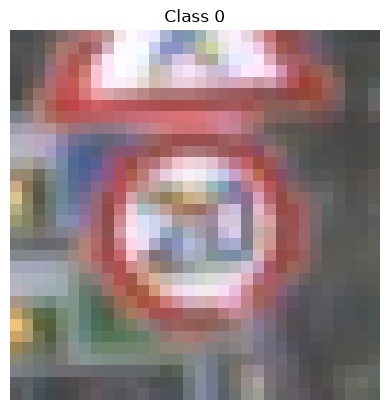

In [14]:
import matplotlib.pyplot as plt
image,label= dataset[0]
plt.imshow(image.permute(1,2,0))
plt.title(f"Class {label}")
plt.axis("off")
plt.show()

In [20]:
from torch.utils.data import random_split
train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size
train_dataset, val_dataset=random_split(
    dataset,[train_size,val_size])
print("Train samples:",len(train_dataset))
print("Validation samples:",len(val_dataset))

Train samples: 31367
Validation samples: 7842


In [21]:
from torch.utils.data import DataLoader 
batch_size=64
train_loader=DataLoader(
    train_dataset,batch_size=batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
print("Train batches:",len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 491
Validation batches: 123


In [22]:
images, labels=next(iter(train_loader))

print("Images shape:",images.shape)
print("Labels shape:",labels.shape)

Images shape: torch.Size([64, 3, 32, 32])
Labels shape: torch.Size([64])


In [28]:

import torch.nn as nn
class TrafficSignCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64,128, kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 43)
        )
    def forward(self,x):
        x=self.features(x)
        x=self.classifier(x)
        return x

In [29]:
model=TrafficSignCNN()
print(model)

TrafficSignCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias

In [30]:
outputs = model(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([64, 43])


In [31]:
import torch.optim as optm
criterion=nn.CrossEntropyLoss()
optimizer=optm.Adam(
    model.parameters(),lr=0.001)

In [34]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)
print(device)

cpu


In [35]:
num_epochs=5
train_losses=[]
val_losses=[]
for epoch in range(num_epochs):
    #let us train
    model.train()
    running_loss=0
    for images,labels in train_loader:
        images=images.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    train_loss=running_loss/len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss=0
    with torch.no_grad():
        for images,labels in val_loader:
            images=images.to(device)
            labels=labels.to(device)
            outputs =model(images)
            loss =criterion(outputs, labels)
            val_loss+=loss.item()
    val_loss/=len(val_loader)
    val_losses.append(val_loss)
    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch 1/5 | Train Loss: 1.0718 | Val Loss: 0.1635
Epoch 2/5 | Train Loss: 0.1407 | Val Loss: 0.0863
Epoch 3/5 | Train Loss: 0.0807 | Val Loss: 0.0409
Epoch 4/5 | Train Loss: 0.0492 | Val Loss: 0.0291
Epoch 5/5 | Train Loss: 0.0424 | Val Loss: 0.0228


In [38]:
ct=0
tt=0
model.eval()
with torch.no_grad():
    for images,labels in val_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)
        _, predicted=torch.max(outputs,1)
        tt+=labels.size(0)
        ct+=(predicted==labels).sum().item()
accuracy=100*ct/tt
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 99.35%


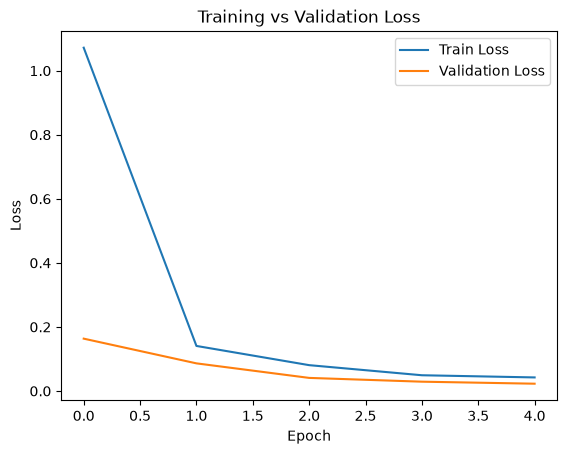

In [39]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [41]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.3 MB 4.9 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 5.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 6.2 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.9 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --- ------------------------------------ 2.9/36.6 MB 15.2 MB/s eta 0:00:03
   -------- ------------------------------- 7.6/36.6 MB 18.8 MB/s eta 0:00:02
   ------------- -------------------------- 12.3/36.6 MB 20.3 MB/s eta 0:00:02
   ------------------- -------------------- 18.1/36.6 MB 21.9 MB/s eta 0:00:01
   -------------------------- ------------- 24.4/36.6 MB 24.1 MB/s eta 0:00:01
   ------------

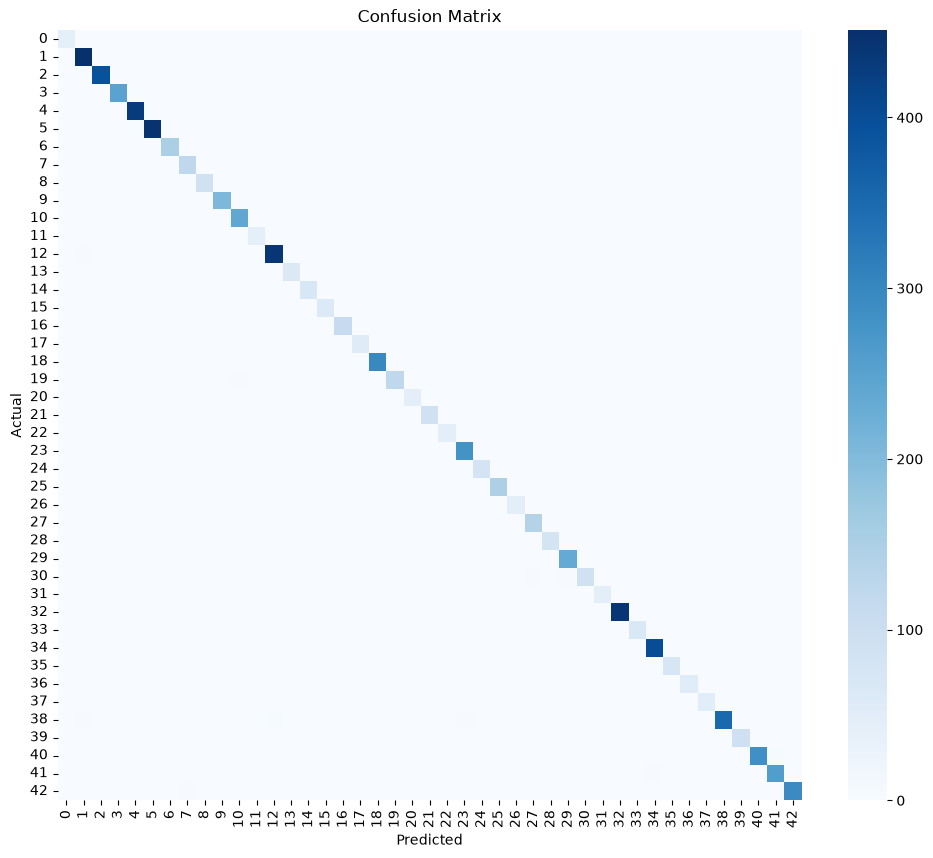

In [42]:

!pip install seaborn
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images=images.to(device)
        outputs=model(images)
        _, preds=torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cmatrix=confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12,10))
sns.heatmap(cmatrix, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

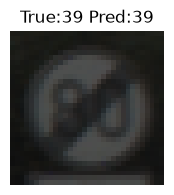

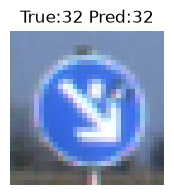

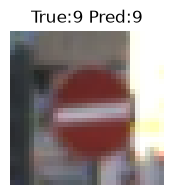

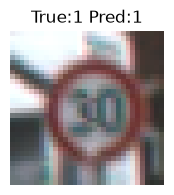

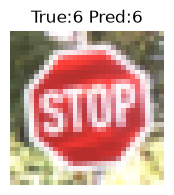

In [43]:
import matplotlib.pyplot as plt
images, labels = next(iter(val_loader))
images=images.to(device)
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
for i in range(5):
    plt.figure(figsize=(2,2))
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.title(
        f"True:{labels[i]} Pred:{preds[i].cpu()}")
    plt.axis("off")
    plt.show()